<a href="https://colab.research.google.com/github/Sanjit-123/DE_workshop/blob/main/DAY-2/DAY_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All librarires imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

All librarires imported successfully
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [ ]:
df=pd.read_csv('student_performance.csv')
print(f"dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"columns: {df.columns.to_list()}")
print("\nFirst 3 rows:")
df.head(3)

dataset loaded: 30 students, 13 columns
columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

cursor.execute("SELECT COUNT(*) FROM students")

count=cursor.fetchone()[0]

print(f"Database 'college.db' created successfully")
print(f"Table 'students' created with {count} rows")

Database 'college.db' created successfully
Table 'students' created with 30 rows


In [ ]:
def run_query(sql, description="student"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql, conn)
  return result
print("Helper function 'run_query' defined successfully")
print("Usage: run_quey(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_quey(sql_string, description_label)


In [ ]:
query1="""SELECT student_id FROM students  Limit 5"""

result1=run_query(query1, "First 5 students")
result1

First 5 students


,student_id
0,1001
1,1002
2,1003
3,1004
4,1005


In [ ]:
querys="""SELECT department, count(*) as num_stds, round(avg(math_score),2) as avf_sci, round(avg(programming_score),2) as avg_prog from students group by department order by avf_sci desc"""
res3=run_query(querys)
res3

student


,department,num_stds,avf_sci,avg_prog
0,Computer Science,13,85.62,89.23
1,Mechanical,6,71.00,49.33
2,Electronics,6,71.00,61.50
3,Civil,5,63.40,40.60


In [ ]:
query4="""select department,count(*) as num_students,round(avg(math_score),2) as avg_math from students group by department having avg_math>70 order by avg_math desc"""
result4=run_query(query4)
print(result4.to_string(index=False))

student
      department  num_students  avg_math
Computer Science            13     85.62
      Mechanical             6     71.00
     Electronics             6     71.00


In [ ]:
query5="""select gender,count(*) as num_students,round(avg(math_score),2) as avg_math from students group by department having avg_math>70 order by avg_math desc"""
result6=run_query(query5)
print(result6.to_string(index=False))

student
gender  num_students  avg_math
  Male            13     85.62
Female             6     71.00
  Male             6     71.00


   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

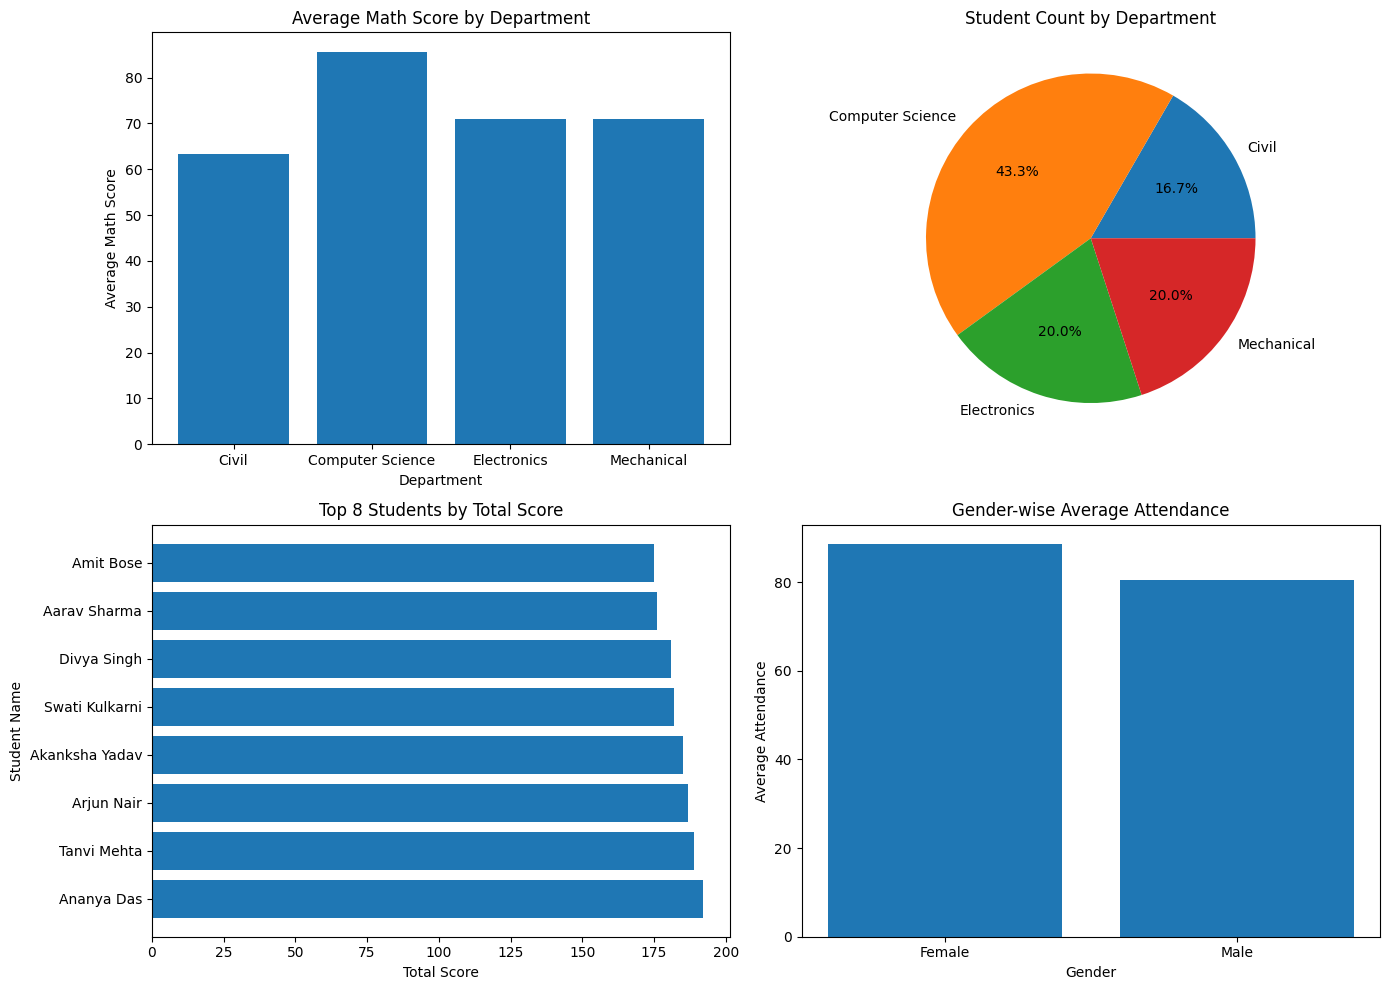


Question 1 Answer
   avg_programming_score
0                   70.2

WHERE Example
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1004   Sneha Reddy   20  Female        Mechanical         2   
3        1005    Arjun Nair   19    Male  Computer Science         2   
4        1008   Divya Singh   19  Female  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          70             80             75                 48   
3          92             88             81                 95   
4          88             91             84                 93   

   attendance_percentage       city  admission_year  
0                     92     Mum

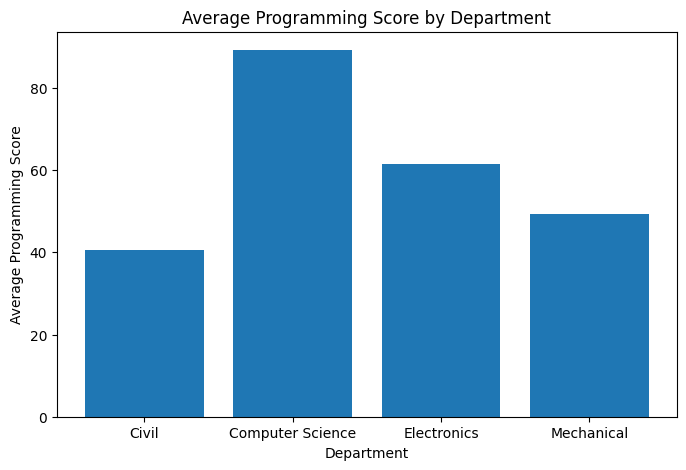

In [1]:
# Day - 2 Mini Project
# Student Dashboard using SQL + Pandas + Matplotlib

# import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from google.colab import files # Import files module
import os

# Check if student_performance.csv exists, if not, prompt for upload
if not os.path.exists("student_performance.csv"):
    print("student_performance.csv not found. Please upload the file.")
    uploaded = files.upload()
    if "student_performance.csv" not in uploaded:
        raise FileNotFoundError("student_performance.csv was not uploaded.")
    print("student_performance.csv uploaded successfully.")

# load csv dataset
df = pd.read_csv("student_performance.csv")

# create sqlite database
conn = sqlite3.connect("student.db")

# store dataframe into sql table
df.to_sql("students", conn, if_exists="replace", index=False)

# check first 5 rows
print(df.head())

# ---------------------------------------------------
# PANEL 1 DATA : Average Math Score by Department
# ---------------------------------------------------

query1 = """
SELECT department, AVG(math_score) AS avg_math_score
FROM students
GROUP BY department
"""

df1 = pd.read_sql_query(query1, conn)

print("\nPanel 1 Data")
print(df1)

# ---------------------------------------------------
# PANEL 2 DATA : Student Count by Department
# ---------------------------------------------------

query2 = """
SELECT department, COUNT(*) AS student_count
FROM students
GROUP BY department
"""

df2 = pd.read_sql_query(query2, conn)

print("\nPanel 2 Data")
print(df2)

# ---------------------------------------------------
# PANEL 3 DATA : Top 8 Students by Total Score
# ---------------------------------------------------

query3 = """
SELECT
    name,
    (math_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

df3 = pd.read_sql_query(query3, conn)

print("\nPanel 3 Data")
print(df3)

# ---------------------------------------------------
# PANEL 4 DATA : Gender-wise Average Attendance
# ---------------------------------------------------

query4 = """
SELECT gender, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY gender
"""

df4 = pd.read_sql_query(query4, conn)

print("\nPanel 4 Data")
print(df4)

# ---------------------------------------------------
# CREATE DASHBOARD
# ---------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1 (top-left): Avg Math by Department - BAR Chart ──

axes[0, 0].bar(df1["department"], df1["avg_math_score"])

axes[0, 0].set_title("Average Math Score by Department")
axes[0, 0].set_xlabel("Department")
axes[0, 0].set_ylabel("Average Math Score")

# ── Panel 2 (top-right): Student Count Pie Chart ──

axes[0, 1].pie(
    df2["student_count"],
    labels=df2["department"],
    autopct="%1.1f%%"
)

axes[0, 1].set_title("Student Count by Department")

# ── Panel 3 (bottom-left): Top 8 Students Horizontal Bar ──

axes[1, 0].barh(df3["name"], df3["total_score"])

axes[1, 0].set_title("Top 8 Students by Total Score")
axes[1, 0].set_xlabel("Total Score")
axes[1, 0].set_ylabel("Student Name")

# ── Panel 4 (bottom-right): Gender Avg Attendance Bar ──

axes[1, 1].bar(df4["gender"], df4["avg_attendance"])

axes[1, 1].set_title("Gender-wise Average Attendance")
axes[1, 1].set_xlabel("Gender")
axes[1, 1].set_ylabel("Average Attendance")

# adjust layout
plt.tight_layout()

# show dashboard
plt.show()

# ---------------------------------------------------
# PRACTICE QUESTIONS
# ---------------------------------------------------

# Question 1
# Average programming score for female students

query_q1 = """
SELECT AVG(programming_score) AS avg_programming_score
FROM students
WHERE gender = 'Female'
"""

result_q1 = pd.read_sql_query(query_q1, conn)

print("\nQuestion 1 Answer")
print(result_q1)

# ---------------------------------------------------

# Question 2
# WHERE vs HAVING examples

# WHERE example
query_where = """
SELECT *
FROM students
WHERE attendance_percentage > 85
"""

# HAVING example
query_having = """
SELECT department, AVG(math_score) AS avg_math
FROM students
GROUP BY department
HAVING AVG(math_score) > 80
"""

print("\nWHERE Example")
print(pd.read_sql_query(query_where, conn).head())

print("\nHAVING Example")
print(pd.read_sql_query(query_having, conn))

# ---------------------------------------------------

# Question 3
# Departments where average attendance > 85

query_q3 = """
SELECT department, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

print("\nQuestion 3 Answer")
print(pd.read_sql_query(query_q3, conn))

# ---------------------------------------------------

# Question 4
# pd.read_sql_query explanation

print("\nQuestion 4 Answer")
print("pd.read_sql_query() returns a Pandas DataFrame")
print("It requires:")
print("1. SQL Query")
print("2. Database Connection Object")

# ---------------------------------------------------

# Question 5
# Modified chart for average programming score

query_q5 = """
SELECT department, AVG(programming_score) AS avg_programming_score
FROM students
GROUP BY department
"""

df_q5 = pd.read_sql_query(query_q5, conn)

plt.figure(figsize=(8, 5))

plt.bar(df_q5["department"], df_q5["avg_programming_score"])

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Programming Score")

plt.show()

# ---------------------------------------------------

# close database connection
conn.close()